# Calogero-Sutherland Model — Exact Wavefunction Test

**Hamiltonian** (convention $\hbar^2/m = 1$, so kinetic $= -\sum_i \partial^2/\partial x_i^2$):

$$H = -\sum_i \frac{\partial^2}{\partial x_i^2} + \sum_i x_i^2 + 2L(L-1) \sum_{i<j} \frac{1}{(x_i - x_j)^2}$$

**Exact ground state:**

$$\psi_0(x) = C \prod_{i<j} |x_i - x_j|^L \cdot \exp\!\left(-\tfrac{1}{2}\sum_i x_i^2\right)$$

$$\log|\psi_0| = L \sum_{i<j} \log|x_i - x_j| - \tfrac{1}{2}\sum_i x_i^2$$

**Exact ground state energy** (in code convention, $\omega=1$):

$$E_0 = N\bigl(1 + L(N-1)\bigr) \qquad \Longrightarrow \qquad E_0/N = 1 + L(N-1)$$

**This notebook trains the exact model** — a single learnable parameter $\lambda$ in the Jastrow factor.
When $\lambda \to L$, the energy converges exactly to $E_0$.

## Imports

In [ ]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.config.training_setup import TrainingConfig, CuspConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.boundaries import NoBoundary
from qvarnet.models.analytic import CalogeroSutherlandAnalyticModel
from qvarnet.models.compose import LogWavefunction
from qvarnet.models.mlp import MLP
from qvarnet.models.envelopes import GaussianEnvelope
from qvarnet.models.jastrow import LogJastrow
from qvarnet.hamiltonian.continuous import CalogeroSutherlandHamiltonian

## System

In [2]:
N_PARTICLES = 5     # number of particles
DIM         = 1
L           = 1.1   # CS coupling; exact λ = L in the Jastrow factor

N_CHAINS = 25_000
DoF      = N_PARTICLES * DIM
SHAPE    = (N_CHAINS, DoF)

# Exact energy in code convention (H = -Σ∂² + V, ω=1)
E_EXACT_TOTAL = N_PARTICLES * (1 + L * (N_PARTICLES - 1))
E_EXACT       = E_EXACT_TOTAL / N_PARTICLES   # per particle

print(f"N = {N_PARTICLES},  L = {L}")
print(f"E₀ (total)      = {E_EXACT_TOTAL:.4f}")
print(f"E₀ (per particle) = {E_EXACT:.4f}")

N = 5,  L = 1.1
E₀ (total)      = 27.0000
E₀ (per particle) = 5.4000


## Model

The `CalogeroSutherlandAnalyticModel` implements the exact log-wavefunction with one learnable parameter $\lambda$:

$$\log|\psi| = \lambda \sum_{i<j} \log|x_i - x_j| - \tfrac{1}{2}\sum_i x_i^2$$

Setting `lambda_init = L` starts at the exact solution. Any other starting value tests convergence.

In [ ]:
LAMBDA_INIT = 1.2   # starting guess for λ; converges to L during training

# model = CalogeroSutherlandAnalyticModel(lambda_init=LAMBDA_INIT)
model = LogWavefunction(
    transform=NoBoundary(),
    network=MLP(hidden=[100]),
    envelope=GaussianEnvelope(),
)
# model = LogWavefunction(
#     transform=NoBoundary(),
#     network=MLP(hidden=[]),    # linear model: no hidden layers
#     envelope=GaussianEnvelope(),
#     jastrow=LogJastrow(n_particles=N_PARTICLES, lambda_init=LAMBDA_INIT),
# )
IS_LOG_MODEL = True

print(f"λ init = {LAMBDA_INIT}   →   target λ = {L}")


## Hamiltonian

`epsilon` softens the $1/(x_i-x_j)^2$ singularity; set it small but nonzero for numerical stability.

In [4]:
hamiltonian = CalogeroSutherlandHamiltonian(L=L, epsilon=1e-4)

## Optimizer

In [5]:
LEARNING_RATE = 0.001
optimizer     = optax.adam(learning_rate=LEARNING_RATE)

## Sampler

In [6]:
CHAIN_LENGTH = 20

sampler_params = {
    "step_size":            0.5,
    "chain_length":         CHAIN_LENGTH + 1,
    "thermalization_steps": CHAIN_LENGTH,
    "thinning_factor":      1,
    "PBC":                  1.0,
}

### Cusp parameters

In [7]:
EPSILON = 1e-2
ALPHA   = 1

## Training

In [8]:
def train_helper(model, epochs, seed1, seed2, with_cusp_condition, n_configs_per_pair, cusp_config=None):
    _cusp_config = CuspConfig(
            epsilon=EPSILON,
            n_configs_per_pair=n_configs_per_pair,
            rng_seed=seed2,
            alpha=ALPHA,
            n=2,       # exponent of the cusp potential term. n -> 1/r^n
            C_n=L,     # expected value of the cusp condition coefficient C_n
        ) if with_cusp_condition else None
    
    # _cusp_config = cusp_config if with_cusp_condition else None
    cfg = TrainingConfig(
        n_epochs=epochs,
        rng_seed=seed1,
        warm_walkers=True,
        is_update_step_size=True,
        min_step=1e-5,
        max_step=5.0,
        cusp=_cusp_config,
    )

    result = train(
        shape=SHAPE,
        model=model,
        optimizer=optimizer,
        hamiltonian=hamiltonian,
        training_config=cfg,
        sampler_params=sampler_params,
        coord_mode=LabCoords(),
    )
    return result.history

# Study of the convergence of the energy with and without the cusp condition in the loss

## Cusp condition enabled

In [ ]:
analytic_model = CalogeroSutherlandAnalyticModel(lambda_init=LAMBDA_INIT)
mlp_gaussian = LogWavefunction(
    transform=NoBoundary(),
    network=MLP(hidden=[128]),
    envelope=GaussianEnvelope(),
)
mlp_jastrow_gaussian = LogWavefunction(
    transform=NoBoundary(),
    network=MLP(hidden=[128]),
    envelope=GaussianEnvelope(),
    jastrow=LogJastrow(n_particles=N_PARTICLES, lambda_init=LAMBDA_INIT),
)

models = {
    # "MLP+Jastrow+Gaussian": mlp_jastrow_gaussian,
    # "Analytic": analytic_model,
    "MLP+Gaussian": mlp_gaussian,
}

n_configs_per_pair = [0, 1,2,10,50, 100]


class ResultsCollector:
    def __init__(self):
        # model_name -> n_configs -> list of run dicts
        self.results = {}

    def add_result(self, model_name, n_configs, history, with_cusp):
        if model_name not in self.results:
            self.results[model_name] = {}
        if n_configs not in self.results[model_name]:
            self.results[model_name][n_configs] = []
        self.results[model_name][n_configs].append({
            "energy":          [float(s.energy) for s in history],
            "std":             [float(s.std) for s in history],
            "acceptance_rate": [float(jnp.mean(s.acceptance_rate)) for s in history],
            "step_size":       [float(s.step_size) for s in history],
            "cusp":            with_cusp,
            "fin_params":      history[-1].params,
        })


collector = ResultsCollector()


for model_name, model in models.items():
    for n_configs in n_configs_per_pair:
        print(n_configs)
        current_seeds = np.random.randint(0, 10000, size=(10, 2))
        if n_configs == 0:
            with_cusp = False  # only cusp condition runs when n_configs=0
        else:
            with_cusp = True
        for seed_tuple in current_seeds:
            print(f"Training {model_name} | n_configs={n_configs} | cusp={with_cusp} | seeds={seed_tuple}")
            history = train_helper(
                model=model, epochs=5_000,
                seed1=seed_tuple[0], seed2=seed_tuple[1],
                with_cusp_condition=with_cusp,
                n_configs_per_pair=n_configs,
            )
            collector.add_result(model_name, n_configs, history, with_cusp)


Model: MLP+Gaussian
0 n_configs


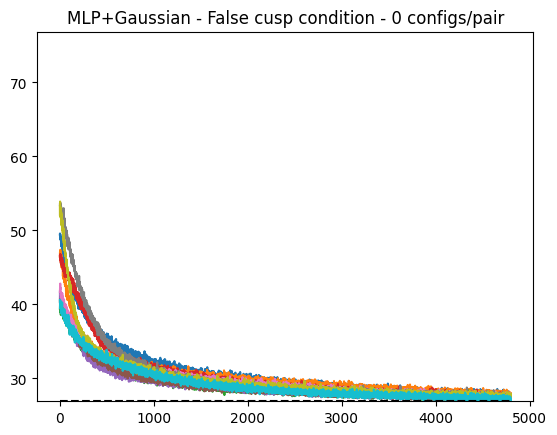

1 n_configs


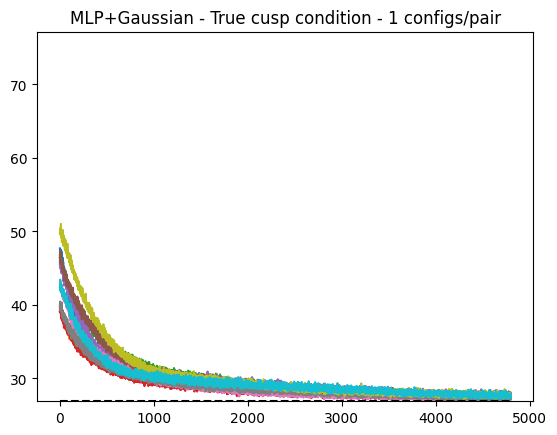

2 n_configs


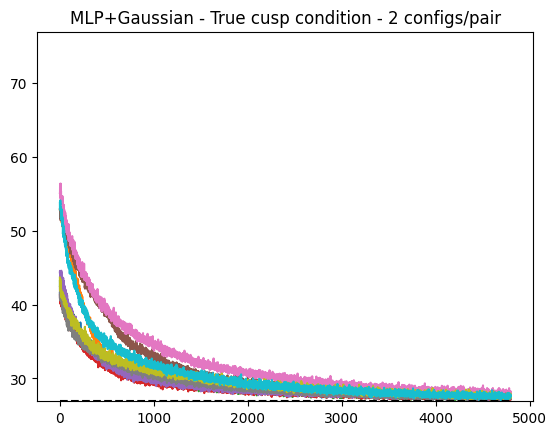

10 n_configs


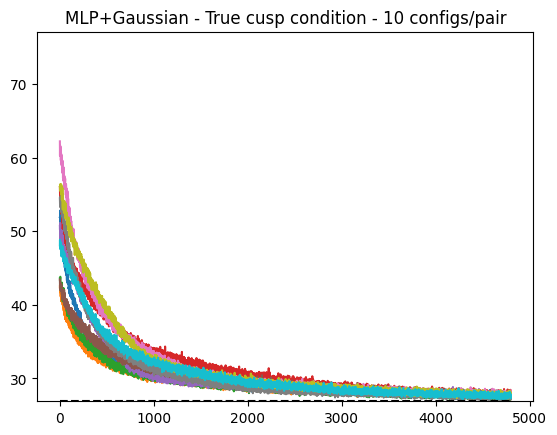

50 n_configs


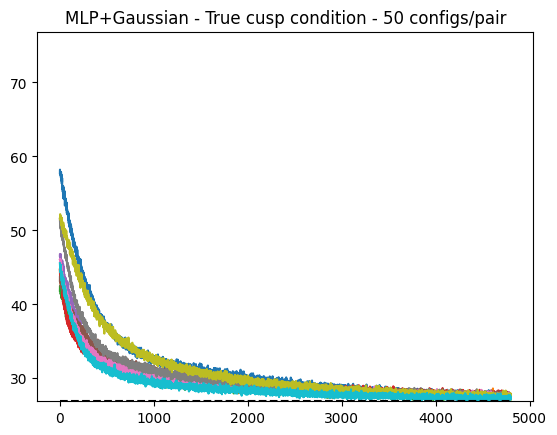

100 n_configs


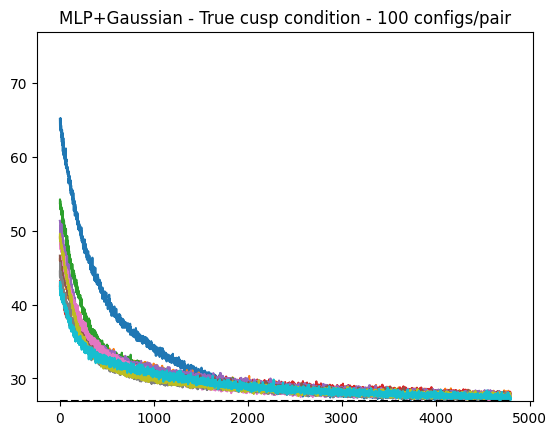

In [10]:
CUTOFF = 200  # skip the first 200 epochs for plotting, as they are usually very noisy and can have large energy values that mess up the scale of the plots

for model_name, model_results in collector.results.items():
    print(f"Model: {model_name}")
    # if model_name == "Analytic":
    for n_configs, results in model_results.items():
        print(n_configs, "n_configs")
        for result in results:
            plt.plot(result["energy"][CUTOFF:], label=f"n_configs={n_configs}, cusp={result['cusp']}")
            if model_name == "Analytic":
                plt.ylim(E_EXACT_TOTAL-0.001, E_EXACT_TOTAL+0.01)
            elif model_name == "MLP+Gaussian":
                plt.ylim(E_EXACT_TOTAL-0.1, min(result["energy"])+50)
        plt.hlines(E_EXACT_TOTAL, 0, len(result["energy"])-CUTOFF, colors='k', linestyles='dashed', label="Exact Energy")
        plt.title(f"{model_name} - {results[0]['cusp']} cusp condition - {n_configs} configs/pair")
        # plt.legend()
        plt.show()

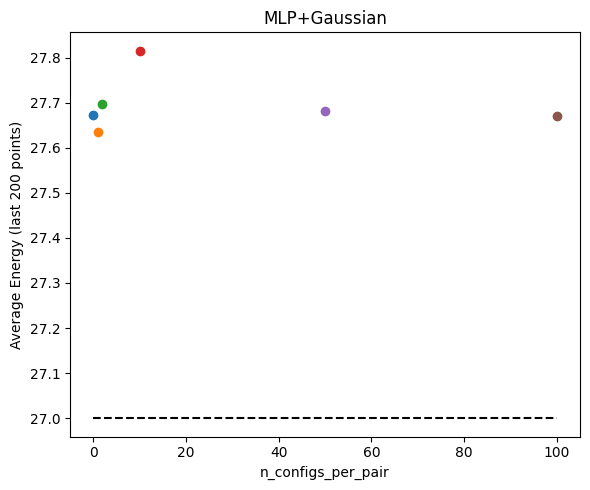

In [12]:
AVG_N_POINTS = 1000 # number of points to average to have a single point in the plot, with a stddev wrt the seeds

fig, ax1 = plt.subplots(figsize=(6, 5))
for model_name, model_results in collector.results.items():
    for n_configs, results in model_results.items():
        N_seeds = len(results)
        
        energy_mean_per_seed = [np.mean(result["energy"][-AVG_N_POINTS:]) for result in results]
        energy_mean = np.mean(energy_mean_per_seed)
        
        # Spread across seeds (S/sqrt(N) term)
        energy_std = np.std(energy_mean_per_seed, ddof=1)
        sem = energy_std / np.sqrt(N_seeds)
        
        # Propagated measurement noise on each seed's mean
        # result["std"] is std of individual samples -> divide by sqrt(AVG_N_POINTS)
        sigma_i = np.array([result["std"] / np.sqrt(AVG_N_POINTS) for result in results])
        propagated = np.sqrt(np.sum(sigma_i**2)) / N_seeds
        
        total_std = np.sqrt(sem**2 + propagated**2)
        total_std = 0
        
        if model_name == "MLP+Gaussian":
            ax1.errorbar(n_configs, energy_mean, yerr=total_std, fmt='o', label=f"{model_name}")
            
ax1.set_title("MLP+Gaussian")
ax1.hlines(E_EXACT_TOTAL, 0, max(n_configs_per_pair), colors='k', linestyles='dashed', label="Exact Energy")
ax1.set_xlabel("n_configs_per_pair")
ax1.set_ylabel("Average Energy (last 200 points)")
plt.tight_layout()
plt.show()
